# 3. Análise Exploratória dos Dados (EDA)

Nesta etapa, vou explorar a base de dados para entender quais fatores podem estar relacionados à satisfação do cliente. Não olhando apenas para números ou gráficos separados, mas tentar responder perguntas que ajudem a entender melhor a experiência do cliente no e-commerce.

Como o projeto fala sobre NPS, vou observar principalmente pontos da jornada que podem afetar a percepção do cliente, como atraso na entrega, contato com o atendimento, reclamações, tempo de resolução e recompra.

As perguntas que vão guiar essa análise são:

1. Clientes com atraso na entrega parecem dar notas menores de NPS?
2. O tempo total de entrega pode influenciar a satisfação?
3. Muitos contatos com atendimento parecem estar ligados a notas mais baixas?
4. Reclamações e maior tempo de resolução podem estar relacionados a mais clientes detratores?
5. Existe algum ponto em que a experiência parece piorar bastante, como muitos dias de atraso ou muitos contatos com atendimento?
6. Clientes que recompraram em até 30 dias parecem ter NPS mais alto?
7. Existem diferenças relevantes por região, idade ou tempo de relacionamento com a empresa?

In [103]:
import pandas as pd

df = pd.read_csv("../data/raw/desafio_nps_fase_1.csv")

df.head()

,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
0,1,63,Nordeste,14,50001,139.73,4,39.35,4,2,2,55.53,3,0,4,6.9,0,3,6.5
1,2,20,Sul,1,50002,458.95,2,9.51,10,6,4,28.23,3,0,10,2.4,0,3,0.0
2,3,46,Nordeste,111,50003,507.06,5,42.82,6,6,1,40.99,1,4,5,4.8,0,7,1.5
3,4,52,Centro-Oeste,117,50004,302.19,2,19.58,9,5,2,35.24,3,1,11,5.9,0,4,0.3
4,5,56,Norte,50,50005,253.06,1,29.37,11,13,1,39.32,1,1,0,6.1,0,3,7.9


In [104]:
# Tamanho da base
df.shape

(2500, 19)

In [105]:
# Informações da base
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customer_id                2500 non-null   int64  
 1   customer_age               2500 non-null   int64  
 2   customer_region            2500 non-null   object 
 3   customer_tenure_months     2500 non-null   int64  
 4   order_id                   2500 non-null   int64  
 5   order_value                2500 non-null   float64
 6   items_quantity             2500 non-null   int64  
 7   discount_value             2500 non-null   float64
 8   payment_installments       2500 non-null   int64  
 9   delivery_time_days         2500 non-null   int64  
 10  delivery_delay_days        2500 non-null   int64  
 11  freight_value              2500 non-null   float64
 12  delivery_attempts          2500 non-null   int64  
 13  customer_service_contacts  2500 non-null   int64

In [106]:
# Verificando se tem dados duplicados
df.duplicated().sum()

np.int64(0)

A base não possui registros duplicados.

In [107]:
# Verificando a distribuição do NPS
df["nps_score"].describe()

count    2500.000000
mean        4.378600
std         2.510229
min         0.000000
25%         2.600000
50%         4.400000
75%         6.100000
max        10.000000
Name: nps_score, dtype: float64

A média do `nps_score` ficou em aproximadamente **4,38** e a mediana em **4,40**. Isso mostra que, nessa base, as notas estão mais concentradas em valores baixos ou intermediários.

Também é possível observar que 75% das notas estão até **6,10**. Então, antes de olhar outras variáveis, parece existir uma quantidade relevante de clientes com uma percepção não tão positiva.

In [108]:
# Classificando os NPS em grupos, sendo até 6 como Detrator, de 6 a 8 como Neutro e acima de 8 como Promotor
def classificar_nps(nota):
    if nota <= 6:
        return "Detrator"
    elif nota <= 8:
        return "Neutro"
    else:
        return "Promotor"

df["nps_group"] = df["nps_score"].apply(classificar_nps)

df["nps_group"].value_counts()

nps_group
Detrator    1851
Neutro       448
Promotor     201
Name: count, dtype: int64

Ao classificar os clientes em **detratores**, **neutros** e **promotores**, a maior parte ficou no grupo de **detratores**. Dos 2500 registros, **1851** clientes deram nota de 0 a 6, enquanto **448** ficaram como **neutros** e apenas **201** como **promotores**.

In [109]:
df["nps_group"].value_counts(normalize=True) * 100

nps_group
Detrator    74.04
Neutro      17.92
Promotor     8.04
Name: proportion, dtype: float64

Ao transformar o NPS em grupos, a maior parte dos clientes ficou como **detrator**. Cerca de **74%** dos registros estão nesse grupo, enquanto **17,92%** são neutros e apenas **8,04%** são promotores.

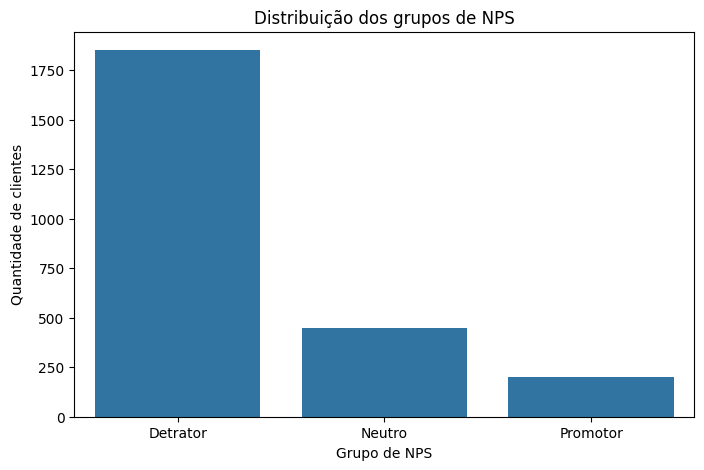

In [110]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="nps_group",
    order=["Detrator", "Neutro", "Promotor"]
)

plt.title("Distribuição dos grupos de NPS")
plt.xlabel("Grupo de NPS")
plt.ylabel("Quantidade de clientes")
plt.show()

O gráfico reforça que a maior parte dos clientes está no grupo de **detratores**. Então existe uma concentração grande de clientes com notas mais baixas de NPS.

## Atraso na Entrega
### Quais fatores parecem mais críticos para a satisfação?

In [111]:
# Criando uma variável para indicar se o pedido teve atraso na entrega
df["has_delivery_delay"] = df["delivery_delay_days"].apply(
    lambda x: "Com atraso" if x > 0 else "Sem atraso" # Se delivery_delay_days for maior que 0, considero que houve atraso
)

df["has_delivery_delay"].value_counts()

has_delivery_delay
Com atraso    2223
Sem atraso     277
Name: count, dtype: int64

A maioria dos pedidos da base aparece como **com atraso**. Dos 2500 registros, 2223 tiveram pelo menos 1 dia de atraso, enquanto apenas 277 não tiveram atraso.

Isso mostra que o atraso é um ponto importante na análise.

In [112]:
# Relacionando pedidos com atraso e sem atraso e o NPS médio de cada um deles
df.groupby("has_delivery_delay")["nps_score"].mean().sort_values()

has_delivery_delay
Com atraso    4.069816
Sem atraso    6.856679
Name: nps_score, dtype: float64

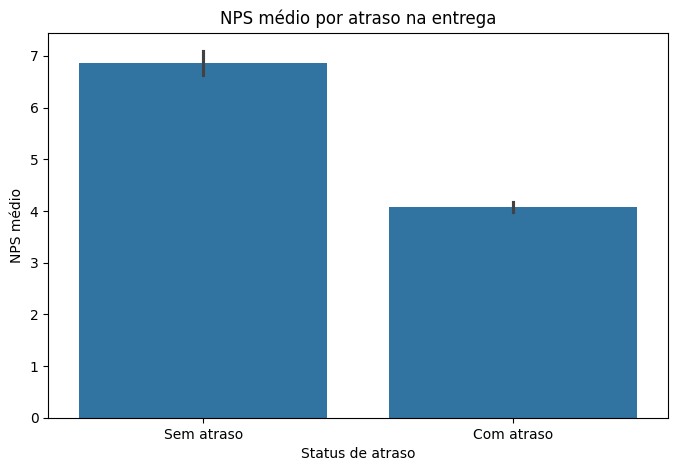

In [113]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x="has_delivery_delay",
    y="nps_score",
    order=["Sem atraso", "Com atraso"]
)

plt.title("NPS médio por atraso na entrega")
plt.xlabel("Status de atraso")
plt.ylabel("NPS médio")
plt.show()

Comparando o NPS médio entre pedidos com atraso e sem atraso, dá para perceber que os clientes **sem atraso** tiveram NPS médio de aproximadamente **6,86**, enquanto os clientes **com atraso** tiveram média de aproximadamente **4,07**.

Isso mostra que o atraso na entrega pode estar ligado a uma nota baixa na experiência do cliente. Ainda não dá para afirmar que o atraso é a única causa dessas notas, porque outros pontos na jornada de compra também podem influenciar.

In [114]:
df["delivery_delay_days"].describe()

count    2500.000000
mean        2.187200
std         1.454442
min         0.000000
25%         1.000000
50%         2.000000
75%         3.000000
max         8.000000
Name: delivery_delay_days, dtype: float64

Os dias de atraso variam de 0 a 8 dias. A média ficou em aproximadamente **2,18 dias** e a mediana em **2 dias**, então boa parte dos pedidos com atraso parece estar concentrada em atrasos pequenos ou moderados.

Também dá para observar que 75% dos pedidos têm **até 3 dias de atraso**. Mesmo assim, existem casos com atrasos maiores, chegando a **8 dias**.

In [115]:
# Criando faixas de atraso para facilitar a comparação com o NPS

def classificar_atraso(dias):
    if dias == 0:
        return "Sem atraso"
    elif dias <= 2:
        return "Atraso baixo (1-2 dias)"
    elif dias <= 4:
        return "Atraso moderado (3-4 dias)"
    else:
        return "Atraso alto (5+ dias)"

df["delivery_delay_group"] = df["delivery_delay_days"].apply(classificar_atraso)

df.groupby("delivery_delay_group")["nps_score"].agg(["count", "mean"]).sort_values("mean", ascending=False)

,count,mean
delivery_delay_group,,
Sem atraso,277,6.856679
Atraso baixo (1-2 dias),1261,5.051308
Atraso moderado (3-4 dias),795,3.099748
Atraso alto (5+ dias),167,1.276647


Separando os atrasos em faixas, dá para perceber que o NPS médio diminui conforme o atraso aumenta. Os pedidos **sem atraso** tiveram a maior média de NPS, enquanto os pedidos com **atraso alto** tiveram a menor média.

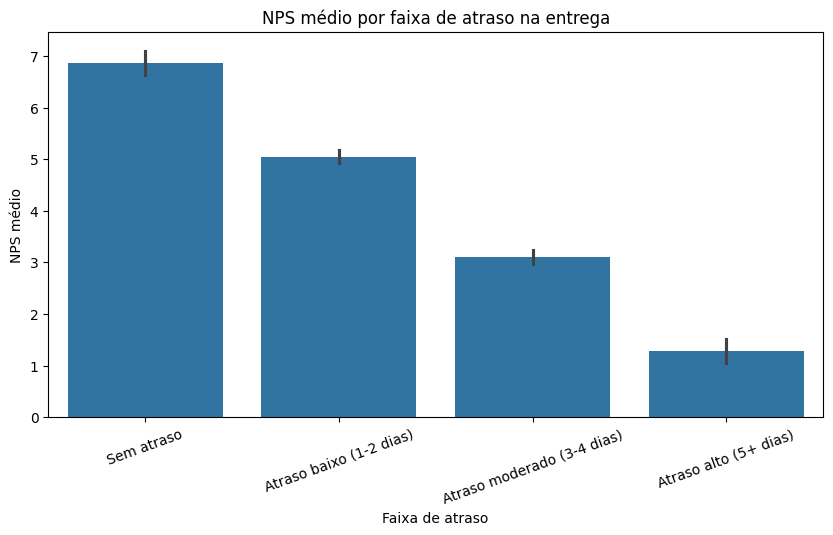

In [116]:
ordem_atraso = [
    "Sem atraso",
    "Atraso baixo (1-2 dias)",
    "Atraso moderado (3-4 dias)",
    "Atraso alto (5+ dias)"
]

plt.figure(figsize=(10, 5))

sns.barplot(
    data=df,
    x="delivery_delay_group",
    y="nps_score",
    order=ordem_atraso
)

plt.title("NPS médio por faixa de atraso na entrega")
plt.xlabel("Faixa de atraso")
plt.ylabel("NPS médio")
plt.xticks(rotation=20)
plt.show()

### Ponto de Ruptura
A queda entre o atraso baixo (1 a 2 dias) e o atraso moderado (3 a 4 dias) cai bastante. Isso pode indicar que, depois de alguns dias de atraso, a nota do cliente piora bastante.

Então atrasos maiores podem ser um **ponto de ruptura** importante na experiência do cliente.

## Contato com o Atendimento
### Quais fatores parecem mais críticos para a satisfação?

In [117]:
# Verificando a distribuição da quantidade de contatos com o atendimento
df["customer_service_contacts"].describe()

count    2500.000000
mean        1.519600
std         1.231512
min         0.000000
25%         1.000000
50%         1.000000
75%         2.000000
max         7.000000
Name: customer_service_contacts, dtype: float64

A quantidade de contatos com atendimento varia de 0 a 7. A média ficou em aproximadamente **1,52 contato** e a mediana em **1 contato**, então muitos clientes parecem ter entrado em contato poucas vezes com o suporte.

Também dá para observar que 75% dos clientes tiveram **até 2 contatos** com atendimento. Mesmo assim, existem casos com mais contatos, chegando a **7**.

Por isso, vale comparar o NPS entre clientes que não precisaram de atendimento, clientes com poucos contatos e clientes com muitos contatos, para entender se essa variável parece estar ligada à satisfação.

In [118]:
# Criando grupos para a quantidade de contatos com atendimento
def classificar_contatos(qtd):
    if qtd == 0:
        return "Nenhum contato"
    elif qtd <= 2:
        return "Poucos contatos (1-2)"
    else:
        return "Muitos contatos (3+)"

df["service_contacts_group"] = df["customer_service_contacts"].apply(classificar_contatos)

# Calculando a quantidade de clientes e o NPS médio para cada grupo
df.groupby("service_contacts_group")["nps_score"].agg(["count", "mean"]).sort_values("mean", ascending=False)

,count,mean
service_contacts_group,,
Nenhum contato,554,5.543502
Poucos contatos (1-2),1456,4.419437
Muitos contatos (3+),490,2.940204


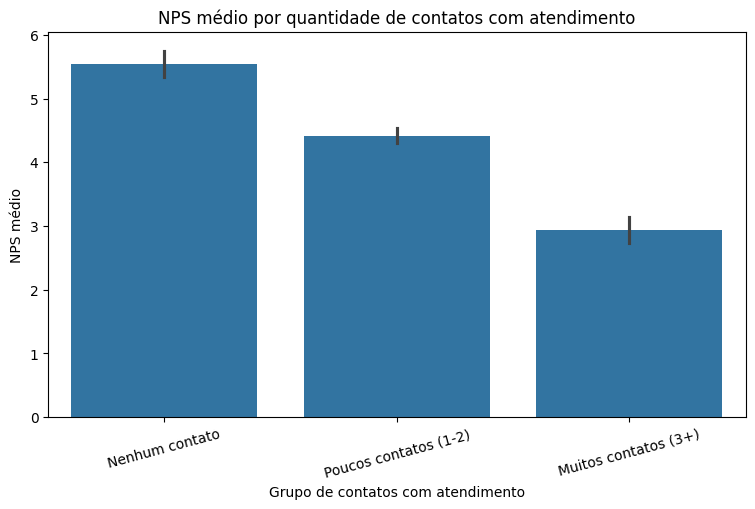

In [119]:
ordem_contatos = [
    "Nenhum contato",
    "Poucos contatos (1-2)",
    "Muitos contatos (3+)"
]

plt.figure(figsize=(9, 5))

sns.barplot(
    data=df,
    x="service_contacts_group",
    y="nps_score",
    order=ordem_contatos
)

plt.title("NPS médio por quantidade de contatos com atendimento")
plt.xlabel("Grupo de contatos com atendimento")
plt.ylabel("NPS médio")
plt.xticks(rotation=15)
plt.show()

O gráfico mostra que o NPS médio diminui conforme aumenta a quantidade de contatos com atendimento. Clientes que não precisaram entrar em contato com o suporte tiveram a maior média de NPS, enquanto clientes com **muitos contatos** tiveram a menor média.

Isso mostra que clientes que precisam falar com o atendimento várias vezes tiveram uma experiência ruim. Mas o contato com atendimento pode não ser a causa da insatisfação, e sim uma consequência de outro problema, como atraso na entrega ou reclamação.

## Reclamações
### Quais fatores parecem mais críticos para a satisfação?

In [120]:
# Verificando a distribuição da quantidade de reclamações
df["complaints_count"].describe()

count    2500.000000
mean        4.150400
std         1.784223
min         0.000000
25%         3.000000
50%         4.000000
75%         5.000000
max        11.000000
Name: complaints_count, dtype: float64

A quantidade de reclamações varia de 0 a 11. A média ficou em aproximadamente **4,15 reclamações** e a mediana em **4 reclamações**.

75% dos clientes tiveram até **5 reclamações**, mas existem casos que chegam a **11 reclamações**. Esses casos podem representar as jornadas com mais problemas ou clientes que tiveram uma experiência mais negativa.

In [121]:
# Criando grupos para a quantidade de reclamações
def classificar_reclamacoes(qtd):
    if qtd == 0:
        return "Nenhuma reclamação"
    elif qtd <= 3:
        return "Poucas reclamações (1-3)"
    elif qtd <= 6:
        return "Reclamações moderadas (4-6)"
    else:
        return "Muitas reclamações (7+)"

df["complaints_group"] = df["complaints_count"].apply(classificar_reclamacoes)

# Calculando a quantidade de clientes e o NPS médio para cada grupo
df.groupby("complaints_group")["nps_score"].agg(["count", "mean"]).sort_values("mean", ascending=False)

,count,mean
complaints_group,,
Nenhuma reclamação,23,8.517391
Poucas reclamações (1-3),906,5.644481
Reclamações moderadas (4-6),1310,3.789695
Muitas reclamações (7+),261,2.575479


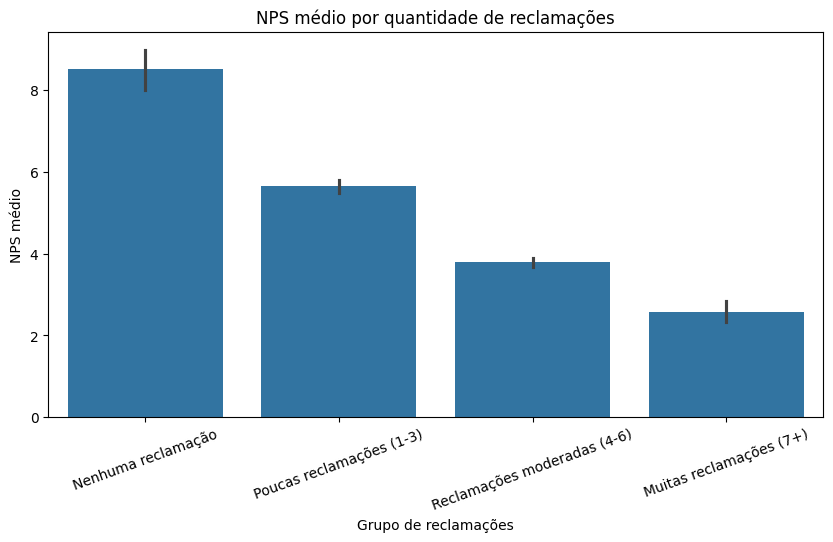

In [122]:
# Definindo a ordem dos grupos de reclamações no gráfico
ordem_reclamacoes = [
    "Nenhuma reclamação",
    "Poucas reclamações (1-3)",
    "Reclamações moderadas (4-6)",
    "Muitas reclamações (7+)"
]

plt.figure(figsize=(10, 5))

sns.barplot(
    data=df,
    x="complaints_group",
    y="nps_score",
    order=ordem_reclamacoes
)

plt.title("NPS médio por quantidade de reclamações")
plt.xlabel("Grupo de reclamações")
plt.ylabel("NPS médio")

plt.xticks(rotation=20)
plt.show()

Analisando a quantidade de reclamações, dá para perceber que o NPS médio diminui conforme o número de reclamações aumenta. Clientes com **nenhuma reclamação** tiveram a maior média de NPS, enquanto clientes com **muitas reclamações** tiveram uma média bem menor.

Esse comportamento faz sentido, porque reclamações indicam que alguma parte da experiência não saiu como o esperado.

## Tempo de Resolução
### Quais fatores parecem mais críticos para a satisfação?

In [123]:
# Verificando a distribuição do tempo de resolução dos problemas
df["resolution_time_days"].describe()

count    2500.000000
mean        5.485600
std         3.458002
min         0.000000
25%         2.000000
50%         6.000000
75%         8.000000
max        11.000000
Name: resolution_time_days, dtype: float64

In [124]:
# Criando grupos para o tempo de resolução dos problemas
def classificar_tempo_resolucao(dias):
    if dias == 0:
        return "Resolvido no mesmo dia / 0 dia"
    elif dias <= 3:
        return "Resolução rápida (1-3 dias)"
    elif dias <= 7:
        return "Resolução média (4-7 dias)"
    else:
        return "Resolução demorada (8+ dias)"

df["resolution_time_group"] = df["resolution_time_days"].apply(classificar_tempo_resolucao)

# Calculando a quantidade de clientes e o NPS médio para cada grupo
df.groupby("resolution_time_group")["nps_score"].agg(["count", "mean"]).sort_values("mean", ascending=False)

,count,mean
resolution_time_group,,
Resolvido no mesmo dia / 0 dia,208,5.320192
Resolução rápida (1-3 dias),658,4.803799
Resolução média (4-7 dias),792,4.359848
Resolução demorada (8+ dias),842,3.831354


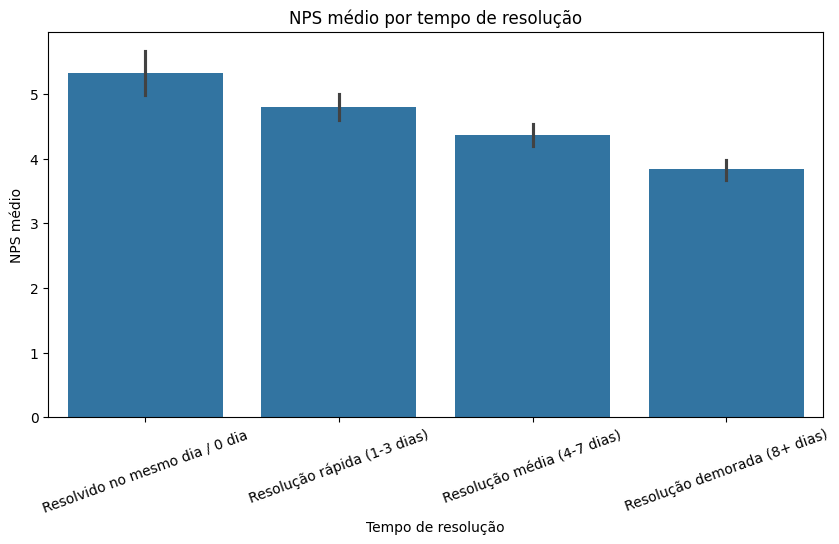

In [125]:
ordem_resolucao = [
    "Resolvido no mesmo dia / 0 dia",
    "Resolução rápida (1-3 dias)",
    "Resolução média (4-7 dias)",
    "Resolução demorada (8+ dias)"
]

plt.figure(figsize=(10, 5))

sns.barplot(
    data=df,
    x="resolution_time_group",
    y="nps_score",
    order=ordem_resolucao
)

plt.title("NPS médio por tempo de resolução")
plt.xlabel("Tempo de resolução")
plt.ylabel("NPS médio")
plt.xticks(rotation=20)
plt.show()

Analisando o tempo de resolução, dá para perceber que o NPS médio tende a diminuir conforme o problema demora mais para ser resolvido. Clientes com resolução no mesmo dia tiveram a **maior média de NPS**, enquanto clientes com resolução demorada (de 8 dias ou mais), tiveram a **menor média**.

A diferença não é tão forte quanto apareceu em atraso na entrega ou reclamações, mas ainda mostra um comportamento importante. Quanto mais tempo a empresa leva para resolver uma situação, pior parece ser a percepção do cliente.

Isso pode indicar que a velocidade de resolução é um ponto relevante para o atendimento acompanhar. Mesmo que o problema já tenha acontecido, **resolver mais rápido** pode ajudar a reduzir o impacto negativo na experiência.

## Recompra (Até 30 dias)
### Quais fatores parecem mais críticos para a satisfação?

In [126]:
# Verificando a quantidade de clientes que recompraram em até 30 dias
df["repeat_purchase_30d"].value_counts()

repeat_purchase_30d
0    2282
1     218
Name: count, dtype: int64

In [127]:
df["repeat_purchase_group"] = df["repeat_purchase_30d"].map({
    0: "Não recomprou", # cliente não recomprou em até 30 dias
    1: "Recomprou"      # cliente recomprou em até 30 dias
})

# Calculando a quantidade de clientes e o NPS médio por grupo de recompra
df.groupby("repeat_purchase_group")["nps_score"].agg(["count", "mean"]).sort_values("mean", ascending=False)

,count,mean
repeat_purchase_group,,
Recomprou,218,9.009633
Não recomprou,2282,3.936196


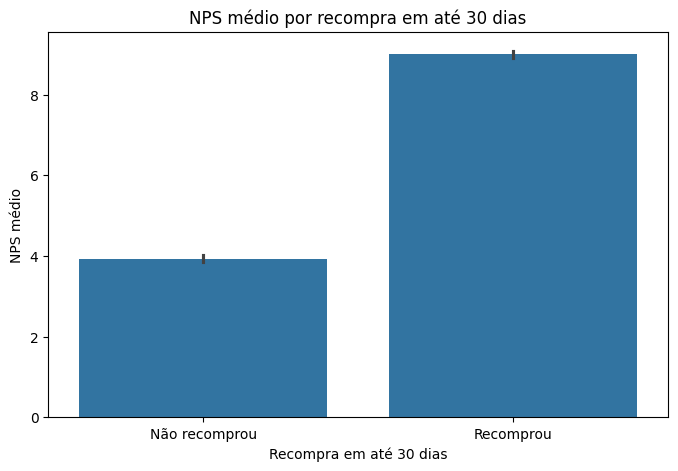

In [128]:
ordem_recompra = [
    "Não recomprou",
    "Recomprou"
]

plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x="repeat_purchase_group",
    y="nps_score",
    order=ordem_recompra
)

plt.title("NPS médio por recompra em até 30 dias")
plt.xlabel("Recompra em até 30 dias")
plt.ylabel("NPS médio")
plt.show()

Comparando os clientes que recompraram em até 30 dias com os que não recompraram, dá para notar uma diferença grande no NPS médio. Os clientes que **recompraram** tiveram uma média bem mais alta, enquanto os clientes que **não recompraram** ficaram com uma média menor.

Isso pode indicar que clientes mais satisfeitos têm mais chance de voltar a comprar. Mas deve notar que o grupo de clientes que recomprou é bem menor do que o grupo que não recomprou.

## Perfil de Cliente por Região
### Que tipo de cliente tende a ter NPS mais alto ou mais baixo?

In [129]:
# Calculando a quantidade de clientes e o NPS médio por região
df.groupby("customer_region")["nps_score"].agg(["count", "mean"]).sort_values("mean", ascending=False)

,count,mean
customer_region,,
Sul,521,4.490979
Nordeste,485,4.421649
Norte,506,4.382609
Sudeste,520,4.373846
Centro-Oeste,468,4.209829


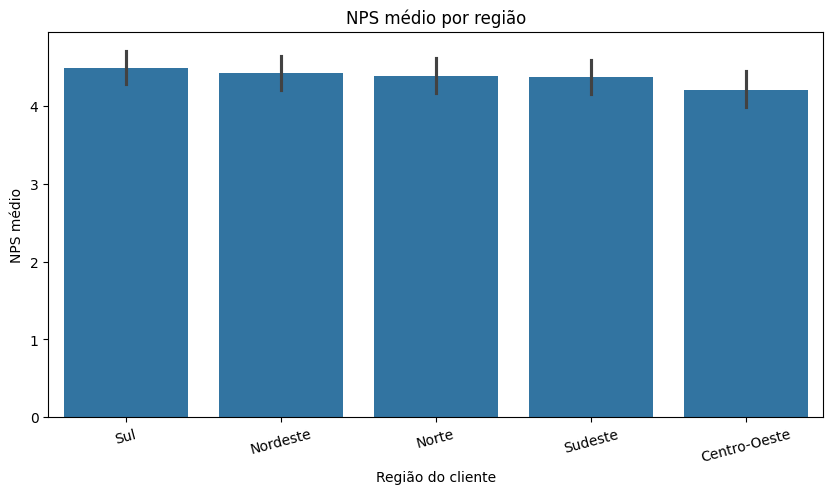

In [130]:
ordem_regiao = (
    df.groupby("customer_region")["nps_score"]
    .mean()
    .sort_values(ascending=False)
    .index
)

plt.figure(figsize=(10, 5))

sns.barplot(
    data=df,
    x="customer_region",
    y="nps_score",
    order=ordem_regiao
)

plt.title("NPS médio por região")
plt.xlabel("Região do cliente")
plt.ylabel("NPS médio")
plt.xticks(rotation=15)
plt.show()

Comparando o NPS médio por região, as diferenças parecem pequenas. A região **Sul** teve a maior média, enquanto o **Centro-Oeste** teve a menor, mas os valores ficaram bem próximos entre si.

Isso pode indicar que a região do cliente, sozinha, não parece ser um dos fatores mais fortes para explicar a variação do NPS nessa base. Diferente de atraso, contato com o atendimento, reclamações ou recompra, a diferença entre regiões não ficou tão marcada.

Mas essa variável pode ser útil em outras análises, principalmente se for combinada com outros fatores, como **prazo de entrega** ou **valor de frete**.

## Tempo de Relacionamento dos Clientes com a Empresa
### Que tipo de cliente tende a ter NPS mais alto ou mais baixo?

In [131]:
# Verifica a distribuição do tempo de relacionamento dos clientes com a empresa
df["customer_tenure_months"].describe()

count    2500.000000
mean       61.322400
std        34.478729
min         1.000000
25%        31.000000
50%        62.000000
75%        91.000000
max       119.000000
Name: customer_tenure_months, dtype: float64

In [132]:
# Criando grupos para o tempo de relacionamento do cliente
def classificar_tempo_cliente(meses):
    if meses <= 24:
        return "Cliente novo (até 2 anos)"
    elif meses <= 60:
        return "Cliente intermediário (2-5 anos)"
    elif meses <= 96:
        return "Cliente antigo (5-8 anos)"
    else:
        return "Cliente muito antigo (8+ anos)"

df["customer_tenure_group"] = df["customer_tenure_months"].apply(classificar_tempo_cliente)

# Calculando a quantidade de clientes e o NPS médio para cada grupo
df.groupby("customer_tenure_group")["nps_score"].agg(["count", "mean"]).sort_values("mean", ascending=False)

,count,mean
customer_tenure_group,,
Cliente antigo (5-8 anos),792,4.467172
Cliente novo (até 2 anos),489,4.401840
Cliente intermediário (2-5 anos),721,4.347989
Cliente muito antigo (8+ anos),498,4.259237


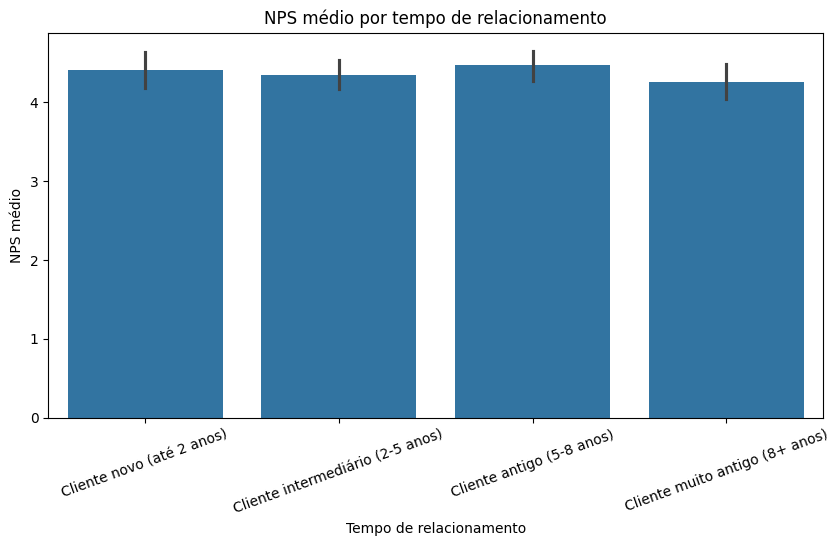

In [133]:
ordem_tempo_cliente = [
    "Cliente novo (até 2 anos)",
    "Cliente intermediário (2-5 anos)",
    "Cliente antigo (5-8 anos)",
    "Cliente muito antigo (8+ anos)"
]

plt.figure(figsize=(10, 5))

sns.barplot(
    data=df,
    x="customer_tenure_group",
    y="nps_score",
    order=ordem_tempo_cliente
)

plt.title("NPS médio por tempo de relacionamento")
plt.xlabel("Tempo de relacionamento")
plt.ylabel("NPS médio")
plt.xticks(rotation=20)
plt.show()

Ao comparar o NPS médio por tempo de relacionamento, as diferenças entre os grupos parecem pequenas. Clientes antigos, entre **5 e 8 anos** de relacionamento, tiveram a maior média de NPS, enquanto clientes muito antigos, com **8 anos ou mais**, tiveram a menor média.

Mesmo assim, os valores ficaram bem próximos. Isso pode indicar que o tempo de relacionamento, sozinho, não parece explicar tanto a variação do NPS nessa base.

Essa variável ainda pode ser útil em outras análises, mas os resultados até aqui mostram que fatores mais ligados à experiência da compra, como atraso, reclamações e recompra, parecem ter uma relação mais forte com a satisfação do cliente.

## Idade do Cliente
### Que tipo de cliente tende a ter NPS mais alto ou mais baixo?

In [134]:
# Verifica a distribuição da idade dos clientes
df["customer_age"].describe()

count    2500.000000
mean       43.396000
std        14.888487
min        18.000000
25%        31.000000
50%        43.000000
75%        56.000000
max        69.000000
Name: customer_age, dtype: float64

In [135]:
# Criando grupos para a idade dos clientes
def classificar_idade(idade):
    if idade <= 30:
        return "18-30 anos"
    elif idade <= 45:
        return "31-45 anos"
    elif idade <= 60:
        return "46-60 anos"
    else:
        return "61+ anos"

df["customer_age_group"] = df["customer_age"].apply(classificar_idade)

# Calculando a quantidade de clientes e o NPS médio para cada faixa etária
df.groupby("customer_age_group")["nps_score"].agg(["count", "mean"]).sort_values("mean", ascending=False)

,count,mean
customer_age_group,,
61+ anos,415,4.563614
18-30 anos,602,4.534551
46-60 anos,714,4.285294
31-45 anos,769,4.243303


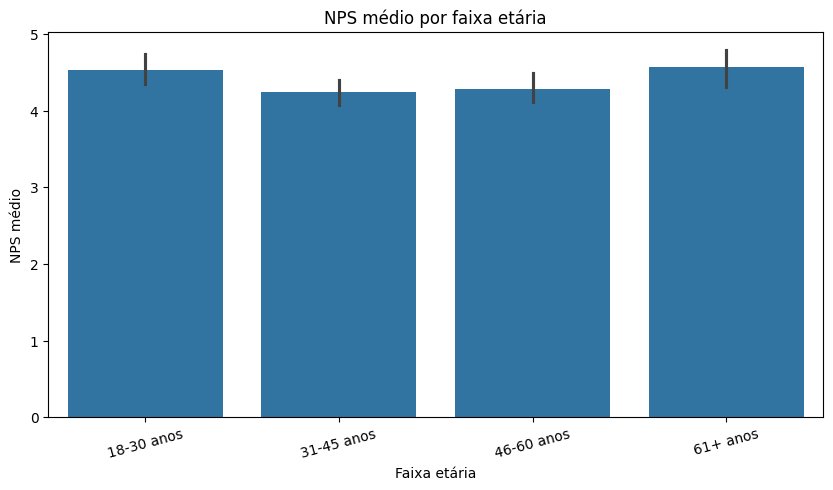

In [136]:
ordem_idade = [
    "18-30 anos",
    "31-45 anos",
    "46-60 anos",
    "61+ anos"
]

plt.figure(figsize=(10, 5))

sns.barplot(
    data=df,
    x="customer_age_group",
    y="nps_score",
    order=ordem_idade
)

plt.title("NPS médio por faixa etária")
plt.xlabel("Faixa etária")
plt.ylabel("NPS médio")
plt.xticks(rotation=15)
plt.show()

Ao comparar o NPS médio por faixa etária, as diferenças entre os grupos parecem pequenas. Os clientes de **61+ anos** tiveram a maior média de NPS, e os clientes de **31 a 45 anos** tiveram a menor média, mas os valores ficaram bem próximos.

Isso pode indicar que a idade, sozinha, não parece ser um fator muito forte para explicar a satisfação do cliente nessa base.

## Resumo dos principais achados da EDA

Com base nas análises feitas, alguns fatores parecem ter uma relação maior com o NPS do que outros. Os pontos que mais chamaram atenção foram **atraso na entrega**, **reclamações**, **contatos com atendimento** e **recompra em até 30 dias**.

O atraso na entrega parece ser um ponto importante. Clientes sem atraso tiveram um NPS médio maior, enquanto clientes com atrasos maiores tiveram notas menores. Quando os atrasos foram separados em faixas, deu para perceber uma queda maior quando o atraso passou de 1 ou 2 dias para 3 ou 4 dias. Isso pode indicar um possível **ponto de ruptura** na experiência do cliente.

As reclamações também parecem ter uma relação forte com o NPS. Clientes com poucas ou nenhuma reclamação tiveram médias mais altas, enquanto clientes com muitas reclamações tiveram médias menores. Isso faz sentido, porque uma reclamação normalmente mostra que alguma parte da experiência não aconteceu como o cliente esperava.

A quantidade de contatos com atendimento também chamou atenção. Clientes que precisaram falar muitas vezes com o suporte tiveram NPS médio menor. Mas o atendimento pode não ser exatamente a causa da insatisfação. Pode ser que o cliente tenha entrado em contato justamente porque já teve algum problema antes, como atraso ou reclamação.

A recompra em até 30 dias foi uma das variáveis com diferença mais clara. Clientes que recompraram tiveram NPS médio bem mais alto do que os clientes que não recompraram. Isso pode indicar que clientes mais satisfeitos tendem a voltar a comprar, o que conecta o NPS com fidelização.

Já as variáveis de perfil, como região, idade e tempo de relacionamento, não mostraram diferenças tão grandes. Elas ajudam a entender melhor a base, mas, nesse caso, a satisfação parece estar mais ligada à experiência da compra do que ao perfil do cliente.

De forma geral, os principais pontos de atenção parecem estar mais ligados à **operação**. A empresa poderia olhar com mais cuidado para **atrasos na entrega**, **volume de reclamações**, **tempo de resolução** e **quantidade de contatos com atendimento**, porque esses fatores parecem estar mais próximos das **notas mais baixas de NPS**.